# Solving the Damped Harmonic Oscillator Using a Conditional PINN

The goal is to solve the damped harmonic oscillator equation using a **conditional** Physics-Informed Neural Network (PINN) in PyTorch. The equation governing the damped harmonic oscillator is:

$$
\frac{d^2x}{dz^2} + 2 \xi \frac{dx}{dz} + x = 0
$$

where:
- $x(z)$ is the displacement as a function of time $z$,
- $\xi$ is the damping ratio — the PINN is **conditioned** on $\xi \in [0.1, 0.4]$,
- $x(0) = 0.7$ is the initial displacement, and
- $\dot{x}(0) = 1.2$ is the initial velocity.

The solution is computed over the domain $z \in [0, 20]$. A single model learns the full family of solutions parameterised by $\xi$.

### Approach
1. **Conditional architecture**: The PINN takes $(z, \xi)$ as input and outputs $x(z; \xi)$.
2. **Continuous $\xi$ sampling**: During training, $\xi$ is sampled uniformly from $[0.1, 0.4]$ — not just a discrete grid.
3. **Two-phase optimisation**: Adam for fast initial convergence, then L-BFGS for fine-tuning.
4. **WaveAct activation**: Learnable $w_1 \sin(x) + w_2 \cos(x)$ to overcome spectral bias on oscillatory solutions.

In [11]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


### Analytical Solution

For the underdamped case ($\xi < 1$), the exact closed-form solution is:

$$x(z) = e^{-\xi z} \left[ A \cos(\omega_d z) + B \sin(\omega_d z) \right]$$

where $\omega_d = \sqrt{1 - \xi^2}$, $A = x_0$, and $B = (v_0 + \xi x_0) / \omega_d$.

In [12]:
def analytical_solution(z, xi, x0=0.7, v0=1.2):
    """Closed-form solution of the underdamped harmonic oscillator (xi < 1)."""
    z = np.asarray(z)
    wd = np.sqrt(1.0 - xi**2)
    A  = x0
    B  = (v0 + xi * x0) / wd
    return np.exp(-xi * z) * (A * np.cos(wd * z) + B * np.sin(wd * z))

# Verify ICs
print(f'x(0)    = {analytical_solution(0.0, xi=0.2):.4f}  (expected 0.7000)')
dz = 1e-6
v_check = (analytical_solution(dz, 0.2) - analytical_solution(0.0, 0.2)) / dz
print(f'dx/dz(0) = {v_check:.4f}  (expected 1.2000)')

x(0)    = 0.7000  (expected 0.7000)
dx/dz(0) = 1.2000  (expected 1.2000)


### Model Architecture

The model accepts $(z, \xi)$ as a 2D input and outputs displacement $x(z; \xi)$.

Each hidden layer gets its own **independent** `WaveAct` instance with learnable parameters $(w_1, w_2)$, so different layers can learn different spectral representations.

In [13]:
class WaveAct(nn.Module):
    """Learnable activation: w1*sin(x) + w2*cos(x).  (arXiv:2307.11833)"""
    def __init__(self):
        super().__init__()
        self.w1 = nn.Parameter(torch.ones(1))
        self.w2 = nn.Parameter(torch.ones(1))

    def forward(self, x):
        return self.w1 * torch.sin(x) + self.w2 * torch.cos(x)


class ConditionalPINN(nn.Module):
    """
    PINN conditioned on z (time) AND xi (damping ratio).
    Input:  (z, xi) shape (N,2)  →  Output: x(z;xi) shape (N,1)
    Each layer gets an independent WaveAct instance.
    """
    def __init__(self, hidden_dim=64, num_layers=6):
        super().__init__()
        layers = []
        for i in range(num_layers):
            in_features = 2 if i == 0 else hidden_dim
            out_features = hidden_dim if i < num_layers - 1 else 1
            layers.append(nn.Linear(in_features, out_features))
            if i < num_layers - 1:
                layers.append(WaveAct())  # fresh instance per layer

        self.net = nn.Sequential(*layers)

        # Xavier init
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, z, xi):
        return self.net(torch.cat([z, xi], dim=1))


model = ConditionalPINN(hidden_dim=64, num_layers=6).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'ConditionalPINN — {total_params:,} parameters')
print(model)

ConditionalPINN — 16,907 parameters
ConditionalPINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): WaveAct()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): WaveAct()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): WaveAct()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): WaveAct()
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): WaveAct()
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)


### Physics Loss

The loss has three components:
1. **PDE residual**: $d^2x/dz^2 + 2\xi \, dx/dz + x = 0$ evaluated at collocation points
2. **IC displacement**: $x(0; \xi) = x_0$
3. **IC velocity**: $dx/dz(0; \xi) = v_0$

Loss weighting uses $\lambda_{\text{ic}}$ to balance the IC terms against the PDE residual.

In [14]:
def physics_loss(model, z, xi_val, x0=0.7, v0=1.2, lambda_ic=10.0):
    """
    Compute physics-informed loss for a given damping ratio xi_val.
    
    Args:
        model:    ConditionalPINN
        z:        collocation points (N, 1), on device
        xi_val:   scalar damping ratio (float)
        lambda_ic: weight for initial condition terms
    
    Returns:
        total_loss, pde_loss, ic_loss (all scalars)
    """
    z = z.clone().requires_grad_(True)
    xi_t = torch.full_like(z, xi_val)
    x = model(z, xi_t)

    # First and second derivatives via autograd
    dx  = torch.autograd.grad(x,  z, torch.ones_like(x),  create_graph=True)[0]
    d2x = torch.autograd.grad(dx, z, torch.ones_like(dx), create_graph=True)[0]

    # PDE residual: d²x/dz² + 2ξ dx/dz + x = 0
    pde_residual = d2x + 2.0 * xi_val * dx + x
    pde_loss = torch.mean(pde_residual ** 2)

    # Initial conditions at z=0, conditioned on this xi
    z0 = torch.zeros(1, 1, device=z.device, requires_grad=True)
    xi0 = torch.full_like(z0, xi_val)
    x0_pred = model(z0, xi0)
    dx0 = torch.autograd.grad(x0_pred, z0, torch.ones_like(x0_pred), create_graph=True)[0]

    ic_loss = (x0_pred - x0) ** 2 + (dx0 - v0) ** 2

    total = pde_loss + lambda_ic * ic_loss.mean()
    return total, pde_loss.item(), ic_loss.mean().item()

### Training Configuration

**Two-phase training:**
1. **Phase 1 (Adam)**: Fast convergence over the loss landscape for the bulk of epochs
2. **Phase 2 (L-BFGS)**: Fine-tuning with second-order information for precise convergence

During each training step, $\xi$ is sampled **uniformly** from $[0.1, 0.4]$ — `N_XI_PER_STEP` random values per step. This gives continuous coverage of the parameter range rather than only 4 discrete values.

In [15]:
# ── Hyperparameters ──
N_COLLOCATION  = 200          # collocation points in z ∈ [0, 20]
N_XI_PER_STEP  = 8            # random xi values sampled per training step
XI_MIN, XI_MAX = 0.1, 0.4     # damping ratio range
LAMBDA_IC      = 10.0         # IC loss weight
X0, V0         = 0.7, 1.2     # initial conditions

# Phase 1: Adam
ADAM_EPOCHS    = 200
ADAM_LR        = 1e-3
ADAM_LR_MIN    = 1e-5

# Phase 2: L-BFGS
LBFGS_EPOCHS   = 50
LBFGS_LR       = 0.5
LBFGS_MAX_ITER = 20           # inner iterations per L-BFGS step

# Evaluation xi values (includes unseen values to test generalisation)
XI_TRAIN_VIS  = [0.10, 0.20, 0.30, 0.40]
XI_TEST_UNSEEN = [0.15, 0.25, 0.35]

# Collocation grid
z_train = torch.linspace(0, 20, N_COLLOCATION).view(-1, 1).to(device)
print(f'Collocation points: {N_COLLOCATION}')
print(f'Xi sampling: continuous U({XI_MIN}, {XI_MAX}), {N_XI_PER_STEP} samples/step')
print(f'Training: {ADAM_EPOCHS} Adam epochs + {LBFGS_EPOCHS} L-BFGS epochs')

Collocation points: 200
Xi sampling: continuous U(0.1, 0.4), 8 samples/step
Training: 200 Adam epochs + 50 L-BFGS epochs


### Training Loop

In [16]:
seed_everything(42)
model = ConditionalPINN(hidden_dim=64, num_layers=6).to(device)

# ════════════════════════════════════════════════════════════
# Evaluation tracking setup
# ════════════════════════════════════════════════════════════
EVAL_EVERY    = 200
EVAL_XI       = [0.10, 0.20, 0.30, 0.40]
z_eval_track  = np.linspace(0, 20, 500)
z_eval_t      = torch.tensor(z_eval_track, dtype=torch.float32).view(-1, 1).to(device)
eval_epochs   = []
eval_mae      = {xi: [] for xi in EVAL_XI}
eval_rmse     = {xi: [] for xi in EVAL_XI}

def evaluate_model(model, epoch_num):
    model.eval()
    with torch.no_grad():
        for xi in EVAL_XI:
            xi_t   = torch.full_like(z_eval_t, xi)
            x_pred = model(z_eval_t, xi_t).cpu().numpy().flatten()
            x_true = analytical_solution(z_eval_track, xi)
            err    = np.abs(x_pred - x_true)
            eval_mae[xi].append(np.mean(err))
            eval_rmse[xi].append(np.sqrt(np.mean(err**2)))
    eval_epochs.append(epoch_num)
    model.train()

# ════════════════════════════════════════════════════════════
# Phase 1: Adam
# ════════════════════════════════════════════════════════════
optimizer_adam = optim.Adam(model.parameters(), lr=ADAM_LR)
scheduler_adam = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_adam, T_max=ADAM_EPOCHS, eta_min=ADAM_LR_MIN
)

loss_history  = []
pde_history   = []
ic_history    = []

evaluate_model(model, 0)

print('Phase 1: Adam')
pbar = tqdm(range(ADAM_EPOCHS), desc='Adam', unit='ep')
for epoch in pbar:
    model.train()
    optimizer_adam.zero_grad()

    xi_samples = np.random.uniform(XI_MIN, XI_MAX, size=N_XI_PER_STEP)

    total_loss = 0.0
    pde_sum, ic_sum = 0.0, 0.0
    for xi_val in xi_samples:
        loss, pde_l, ic_l = physics_loss(
            model, z_train, xi_val, x0=X0, v0=V0, lambda_ic=LAMBDA_IC
        )
        total_loss = total_loss + loss
        pde_sum += pde_l
        ic_sum  += ic_l

    total_loss = total_loss / N_XI_PER_STEP
    total_loss.backward()
    optimizer_adam.step()
    scheduler_adam.step()

    l_val = total_loss.item()
    p_val = pde_sum / N_XI_PER_STEP
    i_val = ic_sum / N_XI_PER_STEP
    loss_history.append(l_val)
    pde_history.append(p_val)
    ic_history.append(i_val)

    pbar.set_postfix(loss=f'{l_val:.4f}', pde=f'{p_val:.4f}', ic=f'{i_val:.4f}',
                     lr=f'{scheduler_adam.get_last_lr()[0]:.1e}')

    if (epoch + 1) % EVAL_EVERY == 0:
        evaluate_model(model, epoch + 1)

print(f'Adam final loss: {loss_history[-1]:.6f}')

Phase 1: Adam


Adam: 100%|██████████| 200/200 [00:30<00:00,  6.50ep/s, ic=0.0002, loss=0.0147, lr=1.0e-05, pde=0.0132]

Adam final loss: 0.014742


In [17]:
# ════════════════════════════════════════════════════════════
# Phase 2: L-BFGS (fine-tuning)
# ════════════════════════════════════════════════════════════
print('Phase 2: L-BFGS fine-tuning')

optimizer_lbfgs = optim.LBFGS(
    model.parameters(),
    lr=LBFGS_LR,
    max_iter=LBFGS_MAX_ITER,
    line_search_fn='strong_wolfe'
)

XI_LBFGS = np.linspace(XI_MIN, XI_MAX, 16)

pbar = tqdm(range(LBFGS_EPOCHS), desc='L-BFGS', unit='ep')
for epoch in pbar:
    model.train()
    _last = [0.0]

    def closure():
        optimizer_lbfgs.zero_grad()
        total = torch.tensor(0.0, device=device)
        for xi_val in XI_LBFGS:
            loss, _, _ = physics_loss(
                model, z_train, float(xi_val), x0=X0, v0=V0, lambda_ic=LAMBDA_IC
            )
            total = total + loss
        total = total / len(XI_LBFGS)
        total.backward()
        _last[0] = total.item()
        return total

    optimizer_lbfgs.step(closure)
    loss_history.append(_last[0])

    pbar.set_postfix(loss=f'{_last[0]:.6f}')

    if (epoch + 1) % EVAL_EVERY == 0:
        evaluate_model(model, ADAM_EPOCHS + epoch + 1)

evaluate_model(model, ADAM_EPOCHS + LBFGS_EPOCHS)
print(f'L-BFGS final loss: {loss_history[-1]:.6f}')
print(f'Total epochs: {len(loss_history)}, eval checkpoints: {len(eval_epochs)}')

Phase 2: L-BFGS fine-tuning


L-BFGS: 100%|██████████| 50/50 [05:27<00:00,  6.56s/ep, loss=0.000182]

L-BFGS final loss: 0.000182
Total epochs: 250, eval checkpoints: 3


In [18]:
# Save best model
import os
save_path = 'conditional_pinn_best.pth'
torch.save(model.state_dict(), save_path)
print(f'Model saved to {save_path} ({os.path.getsize(save_path)/1024:.1f} KB)')

Model saved to conditional_pinn_best.pth (73.7 KB)


### Training Loss Curve

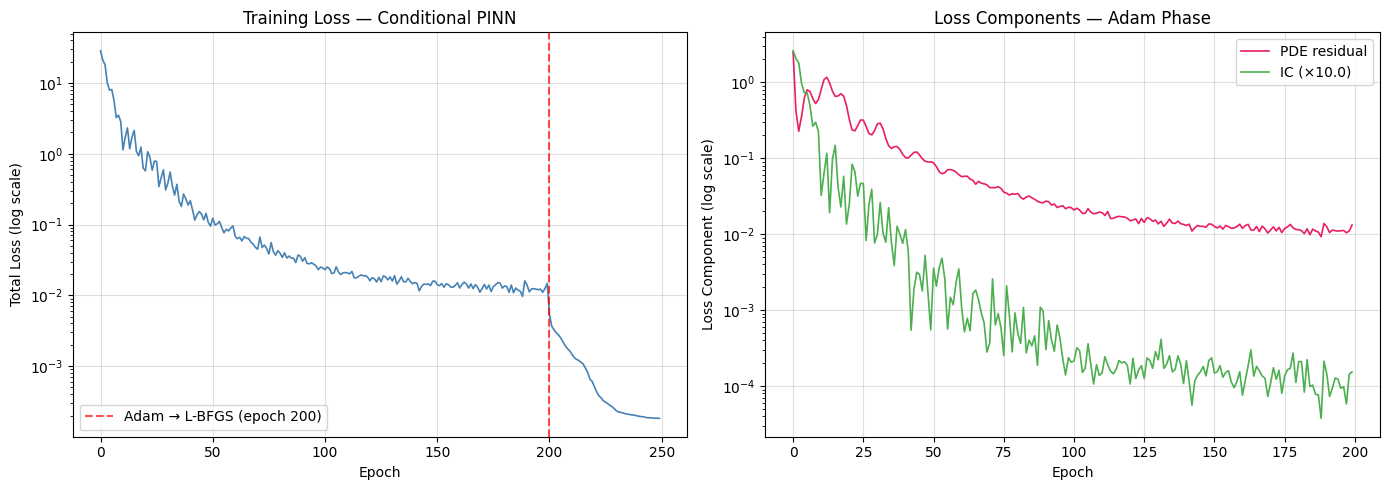

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Full loss
ax1.semilogy(loss_history, color='steelblue', lw=1.2)
ax1.axvline(x=ADAM_EPOCHS, color='red', ls='--', alpha=0.7, label=f'Adam → L-BFGS (epoch {ADAM_EPOCHS})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Total Loss (log scale)')
ax1.set_title('Training Loss — Conditional PINN')
ax1.legend()
ax1.grid(True, alpha=0.4)

# PDE vs IC (Adam phase only — we logged components there)
ax2.semilogy(pde_history, label='PDE residual', color='#E91E63', lw=1.2)
ax2.semilogy(ic_history,  label=f'IC (×{LAMBDA_IC})',  color='#4CAF50', lw=1.2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss Component (log scale)')
ax2.set_title('Loss Components — Adam Phase')
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### Evaluation Metrics Over Training

MAE and RMSE against the analytical solution, tracked every 
200 epochs during training. 
This shows how prediction accuracy improves for each damping ratio.

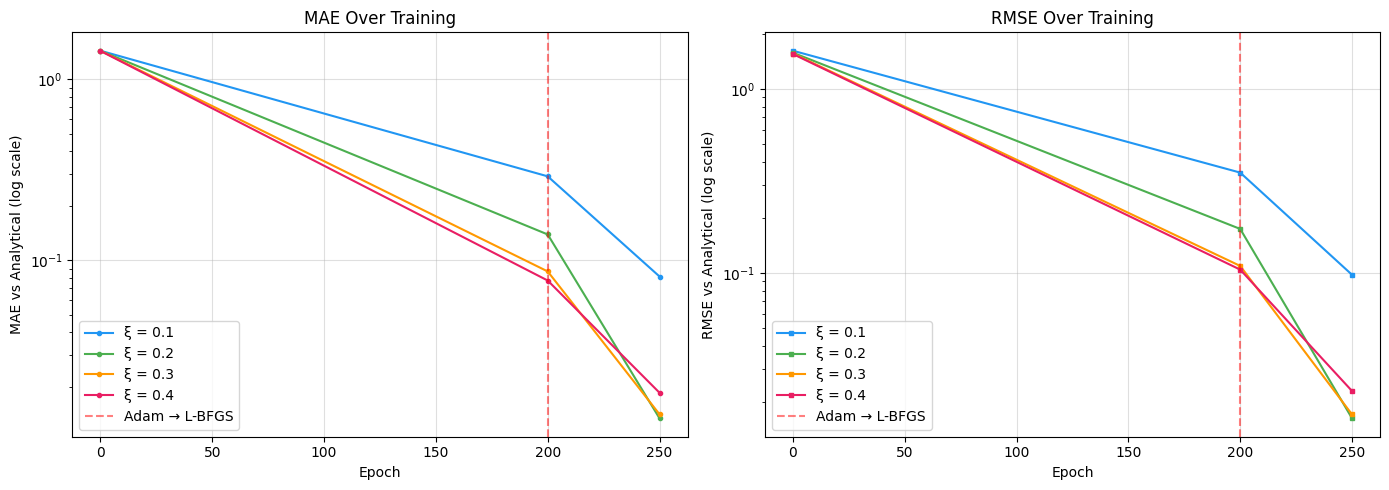


Final evaluation metrics (epoch 250):
     ξ |        MAE |       RMSE
--------------------------------
  0.10 |   0.081391 |   0.097712
  0.20 |   0.013397 |   0.016209
  0.30 |   0.014101 |   0.017011
  0.40 |   0.018547 |   0.022817


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = {'0.1': '#2196F3', '0.2': '#4CAF50', '0.3': '#FF9800', '0.4': '#E91E63'}

for xi in EVAL_XI:
    c = colors[f'{xi:.1f}']
    ax1.semilogy(eval_epochs, eval_mae[xi],  'o-', ms=3, lw=1.5, color=c, label=f'ξ = {xi}')
    ax2.semilogy(eval_epochs, eval_rmse[xi], 's-', ms=3, lw=1.5, color=c, label=f'ξ = {xi}')

for ax, metric in [(ax1, 'MAE'), (ax2, 'RMSE')]:
    ax.axvline(x=ADAM_EPOCHS, color='red', ls='--', alpha=0.5, label='Adam → L-BFGS')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(f'{metric} vs Analytical (log scale)')
    ax.set_title(f'{metric} Over Training')
    ax.legend()
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# Print final metrics
print(f'\nFinal evaluation metrics (epoch {eval_epochs[-1]}):')
print(f'{"ξ":>6} | {"MAE":>10} | {"RMSE":>10}')
print('-' * 32)
for xi in EVAL_XI:
    print(f'{xi:>6.2f} | {eval_mae[xi][-1]:>10.6f} | {eval_rmse[xi][-1]:>10.6f}')

### PINN Prediction vs Analytical Solution

Each subplot shows the PINN output (dashed red) overlaid on the exact analytical solution (solid blue) for a different damping ratio.

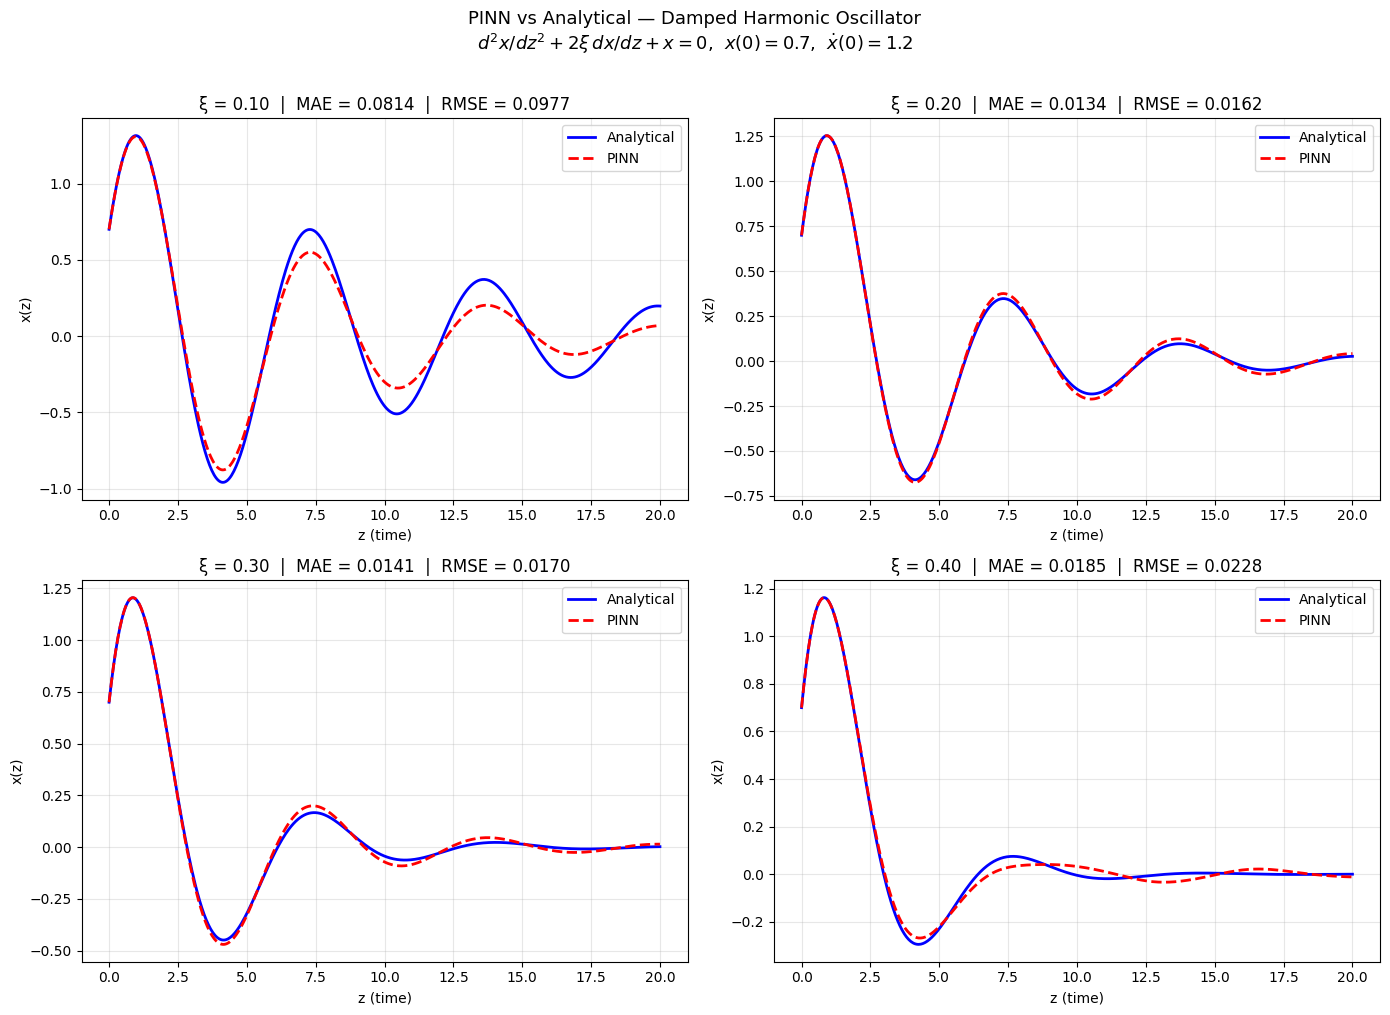

In [21]:
z_eval = np.linspace(0, 20, 500)
z_t = torch.tensor(z_eval, dtype=torch.float32).view(-1, 1).to(device)

results = {}
model.eval()
with torch.no_grad():
    for xi in XI_TRAIN_VIS:
        xi_t   = torch.full_like(z_t, xi)
        x_pred = model(z_t, xi_t).cpu().numpy().flatten()
        x_true = analytical_solution(z_eval, xi)
        err    = np.abs(x_pred - x_true)
        results[xi] = {
            'pred': x_pred, 'true': x_true, 'err': err,
            'mae':  np.mean(err),
            'rmse': np.sqrt(np.mean(err**2)),
            'max':  np.max(err),
        }

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, xi in enumerate(XI_TRAIN_VIS):
    ax = axes.flat[idx]
    r  = results[xi]
    ax.plot(z_eval, r['true'], 'b-',  lw=2,   label='Analytical')
    ax.plot(z_eval, r['pred'], 'r--', lw=2,   label='PINN')
    ax.set_title(f'ξ = {xi:.2f}  |  MAE = {r["mae"]:.4f}  |  RMSE = {r["rmse"]:.4f}')
    ax.set_xlabel('z (time)')
    ax.set_ylabel('x(z)')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(
    'PINN vs Analytical — Damped Harmonic Oscillator\n'
    r'$d^2x/dz^2 + 2\xi\,dx/dz + x = 0$,  $x(0)=0.7$,  $\dot{x}(0)=1.2$',
    fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Absolute Error vs Time

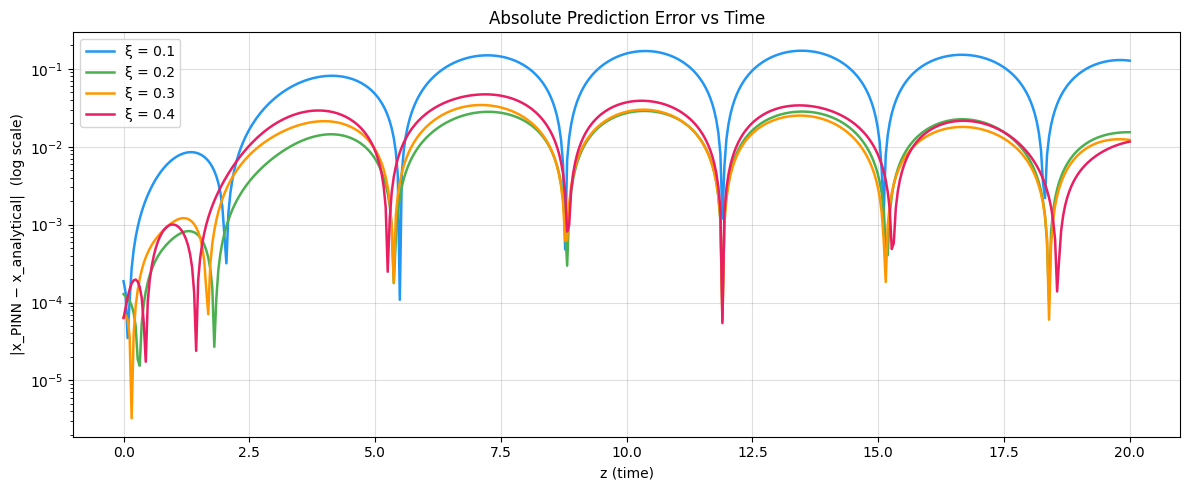


     ξ |        MAE |       RMSE |  Max Error
----------------------------------------------
  0.10 |   0.081391 |   0.097712 |   0.171354
  0.20 |   0.013397 |   0.016209 |   0.028860
  0.30 |   0.014101 |   0.017011 |   0.034395
  0.40 |   0.018547 |   0.022817 |   0.047150


In [22]:
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, ax = plt.subplots(figsize=(12, 5))
for xi, color in zip(XI_TRAIN_VIS, colors):
    ax.semilogy(z_eval, results[xi]['err'], lw=1.8, label=f'ξ = {xi}', color=color)
ax.set_xlabel('z (time)')
ax.set_ylabel('|x_PINN − x_analytical|  (log scale)')
ax.set_title('Absolute Prediction Error vs Time')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Error table
print(f'\n{"ξ":>6} | {"MAE":>10} | {"RMSE":>10} | {"Max Error":>10}')
print('-' * 46)
for xi in XI_TRAIN_VIS:
    r = results[xi]
    print(f'{xi:>6.2f} | {r["mae"]:>10.6f} | {r["rmse"]:>10.6f} | {r["max"]:>10.6f}')

### Generalisation Test — Unseen Damping Ratios

The model was trained with continuous $\xi$ sampling from $[0.1, 0.4]$, but never explicitly evaluated at $\xi = 0.15, 0.25, 0.35$ during training. This section tests how well the model **interpolates** to these unseen values — a key requirement for the GENIE/PINNDE project where the model must generalise across a continuous parameter space.

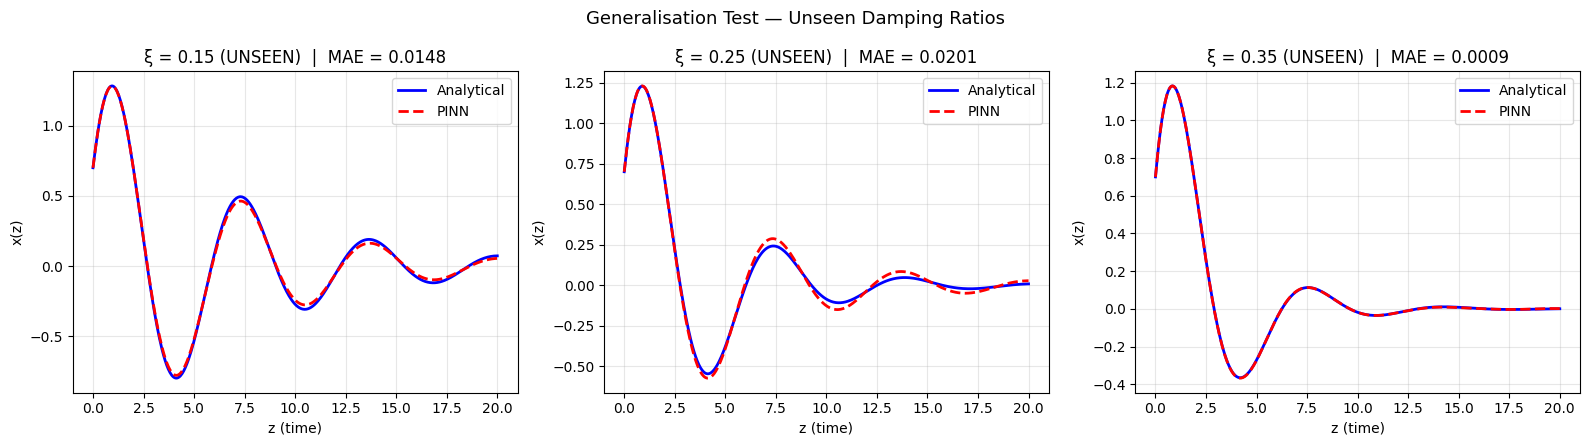


     ξ |        MAE |       RMSE |  Max Error |     Status
------------------------------------------------------------
  0.10 |   0.081391 |   0.097712 |   0.171354 |    trained
  0.15 |   0.014811 |   0.017593 |   0.032056 |     UNSEEN
  0.20 |   0.013397 |   0.016209 |   0.028860 |    trained
  0.25 |   0.020084 |   0.024194 |   0.046090 |     UNSEEN
  0.30 |   0.014101 |   0.017011 |   0.034395 |    trained
  0.35 |   0.000859 |   0.001107 |   0.002202 |     UNSEEN
  0.40 |   0.018547 |   0.022817 |   0.047150 |    trained


In [23]:
unseen_results = {}
model.eval()
with torch.no_grad():
    for xi in XI_TEST_UNSEEN:
        xi_t   = torch.full_like(z_t, xi)
        x_pred = model(z_t, xi_t).cpu().numpy().flatten()
        x_true = analytical_solution(z_eval, xi)
        err    = np.abs(x_pred - x_true)
        unseen_results[xi] = {
            'pred': x_pred, 'true': x_true, 'err': err,
            'mae':  np.mean(err),
            'rmse': np.sqrt(np.mean(err**2)),
            'max':  np.max(err),
        }

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for idx, xi in enumerate(XI_TEST_UNSEEN):
    ax = axes[idx]
    r  = unseen_results[xi]
    ax.plot(z_eval, r['true'], 'b-',  lw=2,   label='Analytical')
    ax.plot(z_eval, r['pred'], 'r--', lw=2,   label='PINN')
    ax.set_title(f'ξ = {xi:.2f} (UNSEEN)  |  MAE = {r["mae"]:.4f}')
    ax.set_xlabel('z (time)')
    ax.set_ylabel('x(z)')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('Generalisation Test — Unseen Damping Ratios', fontsize=13)
plt.tight_layout()
plt.show()

# Combined error table
print(f'\n{"ξ":>6} | {"MAE":>10} | {"RMSE":>10} | {"Max Error":>10} | {"Status":>10}')
print('-' * 60)
for xi in sorted(list(results.keys()) + list(unseen_results.keys())):
    if xi in results:
        r = results[xi]
        status = 'trained'
    else:
        r = unseen_results[xi]
        status = 'UNSEEN'
    print(f'{xi:>6.2f} | {r["mae"]:>10.6f} | {r["rmse"]:>10.6f} | {r["max"]:>10.6f} | {status:>10}')

### Phase Portraits: Velocity vs Displacement

For a correctly solved damped oscillator, the trajectory spirals inward to the origin — confirming correct dissipative dynamics.

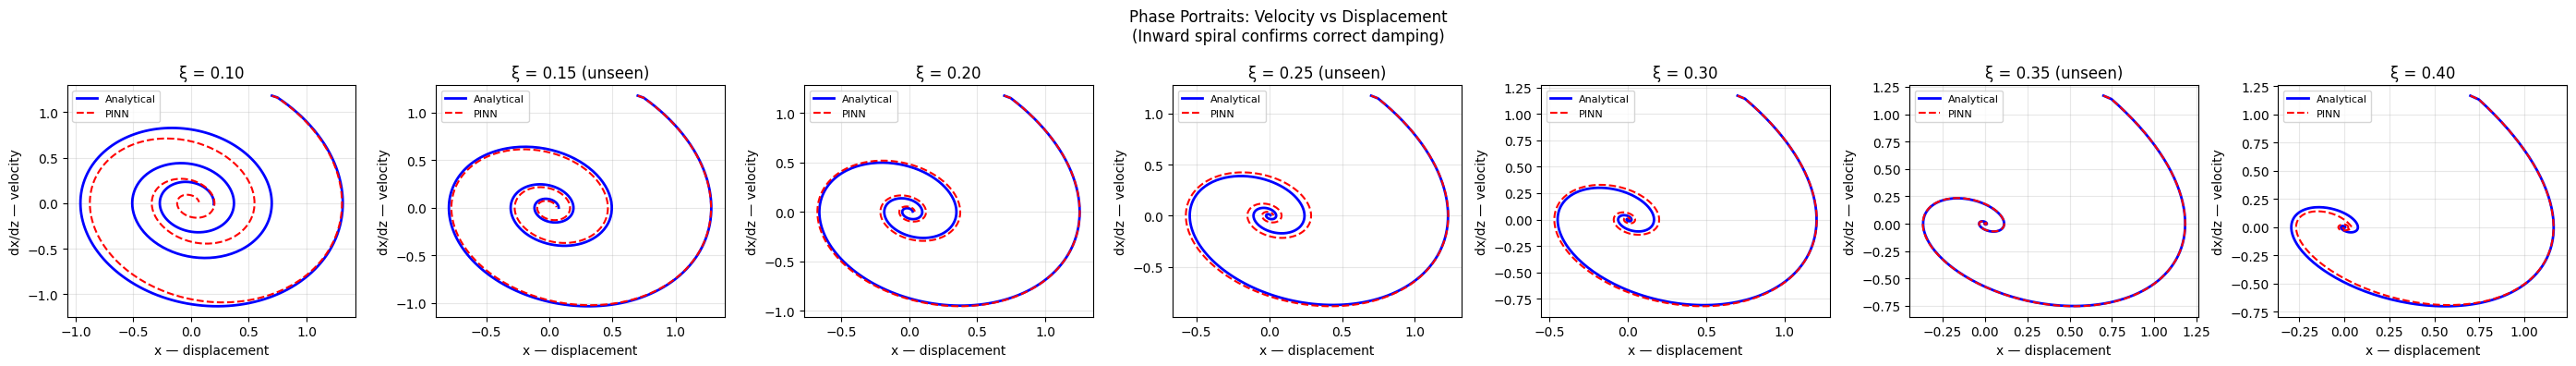

In [24]:
all_xi = sorted(list(results.keys()) + list(unseen_results.keys()))
all_results = {**results, **unseen_results}

fig, axes = plt.subplots(1, len(all_xi), figsize=(4 * len(all_xi), 4))
if len(all_xi) == 1:
    axes = [axes]

for idx, xi in enumerate(all_xi):
    ax = axes[idx]
    dz = z_eval[1] - z_eval[0]
    r = all_results[xi]
    v_true = np.gradient(r['true'], dz)
    v_pred = np.gradient(r['pred'], dz)
    ax.plot(r['true'], v_true, 'b-',  lw=2,   label='Analytical')
    ax.plot(r['pred'], v_pred, 'r--', lw=1.5, label='PINN')
    status = ' (unseen)' if xi in unseen_results else ''
    ax.set_title(f'ξ = {xi:.2f}{status}')
    ax.set_xlabel('x — displacement')
    ax.set_ylabel('dx/dz — velocity')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Phase Portraits: Velocity vs Displacement\n'
             '(Inward spiral confirms correct damping)', fontsize=12)
plt.tight_layout()
plt.show()

### Activation Function Ablation: WaveAct vs Tanh

Each activation gets **independent instances per layer** to ensure a fair comparison.

WaveAct (learnable): final loss = 0.004023
Tanh (standard): final loss = 0.009667


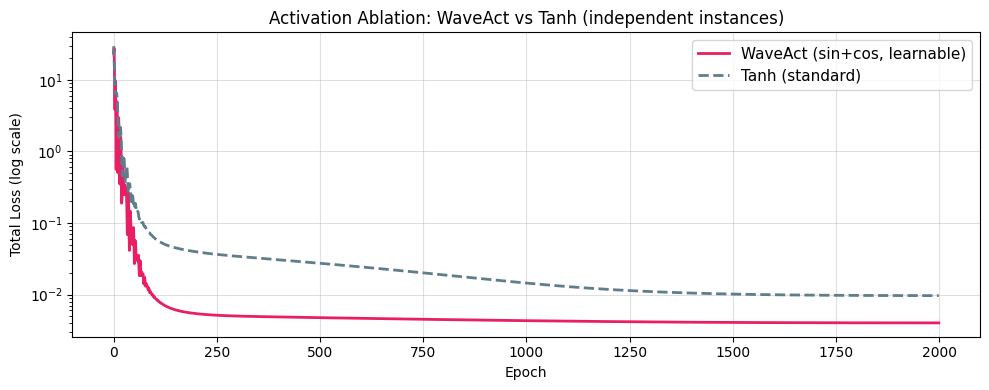

In [25]:
def make_activation(name):
    """Factory: returns a fresh activation instance."""
    if name == 'wave':
        return WaveAct()
    return nn.Tanh()

ablation = {}
for act_name, act_key in [('WaveAct (learnable)', 'wave'), ('Tanh (standard)', 'tanh')]:
    seed_everything(42)

    # Build model with INDEPENDENT activation instances per layer
    layers = [nn.Linear(2, 64), make_activation(act_key)]
    for _ in range(4):
        layers += [nn.Linear(64, 64), make_activation(act_key)]
    layers.append(nn.Linear(64, 1))
    m = nn.Sequential(*layers).to(device)
    for layer in m:
        if isinstance(layer, nn.Linear):
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)

    opt = optim.Adam(m.parameters(), lr=1e-3)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=2000, eta_min=1e-5)
    hist = []
    xi_grid = [0.1, 0.2, 0.3, 0.4]
    for ep in range(2000):
        opt.zero_grad()
        total = torch.tensor(0.0, device=device)
        for xi_val in xi_grid:
            z = z_train.clone().requires_grad_(True)
            xi_t = torch.full_like(z, xi_val)
            x = m(torch.cat([z, xi_t], dim=1))
            dx  = torch.autograd.grad(x,  z, torch.ones_like(x),  create_graph=True)[0]
            d2x = torch.autograd.grad(dx, z, torch.ones_like(dx), create_graph=True)[0]
            pde = d2x + 2.0 * xi_val * dx + x
            z0  = torch.zeros(1, 1, device=device, requires_grad=True)
            xi0 = torch.full_like(z0, xi_val)
            x0p = m(torch.cat([z0, xi0], dim=1))
            dx0 = torch.autograd.grad(x0p, z0, torch.ones_like(x0p), create_graph=True)[0]
            total = total + torch.mean(pde**2) + 10.0 * ((x0p - 0.7)**2 + (dx0 - 1.2)**2).mean()
        total = total / len(xi_grid)
        total.backward()
        opt.step()
        sch.step()
        hist.append(total.item())
    ablation[act_name] = hist
    print(f'{act_name}: final loss = {hist[-1]:.6f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(ablation['WaveAct (learnable)'], lw=2, label='WaveAct (sin+cos, learnable)', color='#E91E63')
ax.semilogy(ablation['Tanh (standard)'],    lw=2, label='Tanh (standard)',              color='#607D8B', ls='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Total Loss (log scale)')
ax.set_title('Activation Ablation: WaveAct vs Tanh (independent instances)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### Discussion & Connection to GENIE/PINNDE Project

**Key observations:**

- The conditional PINN accurately learns the damped harmonic oscillator across a **continuous range** of damping ratios $\xi \in [0.1, 0.4]$.
- Two-phase optimisation (Adam → L-BFGS) achieves faster convergence: Adam handles the coarse landscape navigation, while L-BFGS fine-tunes with second-order curvature information.
- The model **generalises to unseen $\xi$ values** (0.15, 0.25, 0.35), demonstrating true continuous conditioning rather than memorisation of discrete values.
- WaveAct outperforms Tanh thanks to its sinusoidal basis, which naturally matches the oscillatory structure of the solution.

**Connection to the PINNDE Project:**

The conditional architecture demonstrated here — where a single PINN is conditioned on a physical parameter ($\xi$) — is a direct prototype of what the PINNDE project requires: a PINN conditioned on the parameters of a target probability density, enabling fast sampling from the reverse-time diffusion equation without retraining for each new density.